In [1]:
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, CenteredNorm
import numpy as np
from copy import deepcopy
from pprint import pprint
from pyHalo.preset_models import preset_model_from_name

from mejiro.analysis import stats
from mejiro.exposure import Exposure
from mejiro.instruments.roman import Roman
from mejiro.galaxy_galaxy import Sample1, Sample2, SampleGG
from mejiro.synthetic_image import SyntheticImage
from mejiro.utils import lenstronomy_util
from mejiro.engines.galsim_engine import GalSimEngine
from mejiro.engines.stpsf_engine import STPSFEngine

In [2]:
strong_lens = Sample1()
strong_lens.use_jax = [True] * 4

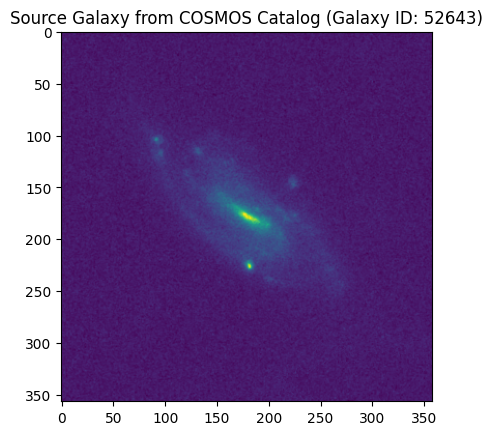

In [3]:
plt.imshow(strong_lens.kwargs_source[0]['image'])
plt.title(f'Source Galaxy from COSMOS Catalog (Galaxy ID: {strong_lens.physical_params["galaxy_id"]})')
plt.show()

W0402 16:34:05.453578 1297986 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0402 16:34:05.455268 1297985 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0402 16:34:05.456453 1297987 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0402 16:34:05.460852 1297741 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0402 16:34:05.461744 1297741 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0402 16:34:05.463070 1297741 cuda_executor.cc:1802] GPU int

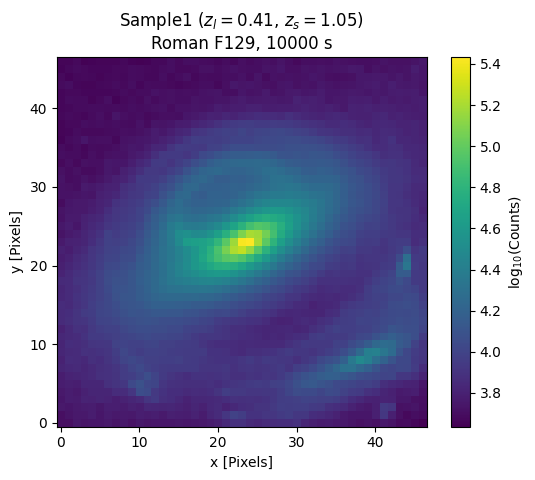

In [4]:
roman = Roman()

synthetic_image = SyntheticImage(strong_lens,
                                 instrument=roman,
                                 band='F129',
                                 fov_arcsec=5,
                                #  instrument_params=instrument_params,
                                #  kwargs_numerics=kwargs_numerics,
                                #  kwargs_psf=kwargs_psf,
                                 pieces=True)

exposure = Exposure(synthetic_image,
                        exposure_time=10000)

engine_params = {
        'poisson_noise': exposure.poisson_noise,
        'reciprocity_failure': exposure.reciprocity_failure,
        'dark_noise': exposure.dark_noise,
        'nonlinearity': exposure.nonlinearity,
        'ipc': exposure.ipc,
        'read_noise': exposure.read_noise
    }

exposure.plot()

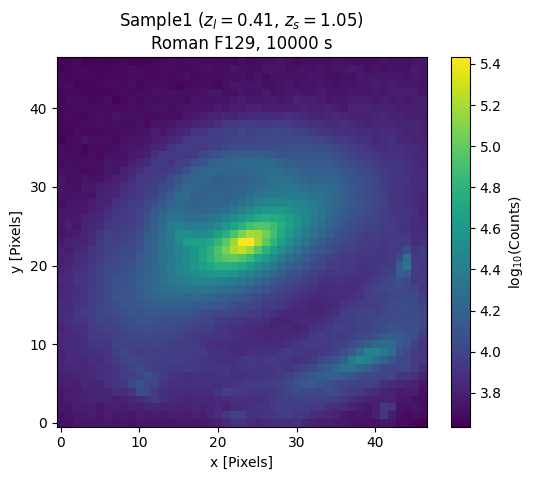

In [5]:
strong_lens_with_substructure = deepcopy(strong_lens)
ULDM = preset_model_from_name('ULDM')
realization = ULDM(round(strong_lens_with_substructure.z_lens, 2),
                               round(strong_lens_with_substructure.z_source, 2),
                               log10_m_uldm=-22,
                               cone_opening_angle_arcsec=5,
                               log_m_host=np.log10(strong_lens_with_substructure.get_main_halo_mass()),
                               flucs_shape='ring',
                               flucs_args={'angle': 0.0, 'rmin': 0.9, 'rmax': 1.1},
                               log10_fluc_amplitude=-1.6,
                               n_cut=10000)
strong_lens_with_substructure.add_realization(realization, use_jax=True)

synthetic_image_with_substructure = SyntheticImage(strong_lens_with_substructure,
                                 instrument=roman,
                                 band='F129',
                                 fov_arcsec=5,
                                #  instrument_params=instrument_params,
                                #  kwargs_numerics=kwargs_numerics,
                                #  kwargs_psf=kwargs_psf,
                                 pieces=True)

exposure_with_substructure = Exposure(synthetic_image_with_substructure,
                        exposure_time=10000,
                        engine_params=engine_params)

exposure_with_substructure.plot()

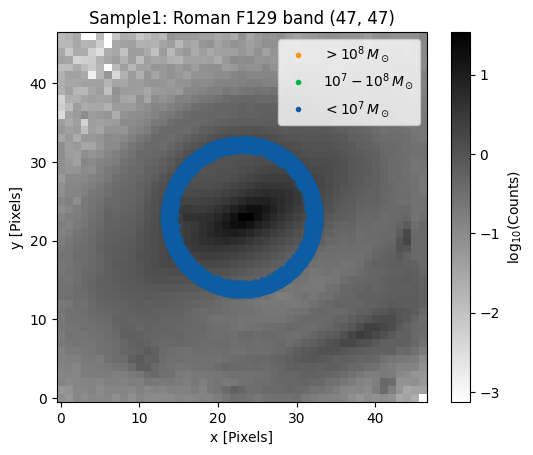

In [6]:
synthetic_image_with_substructure.overplot_subhalos()

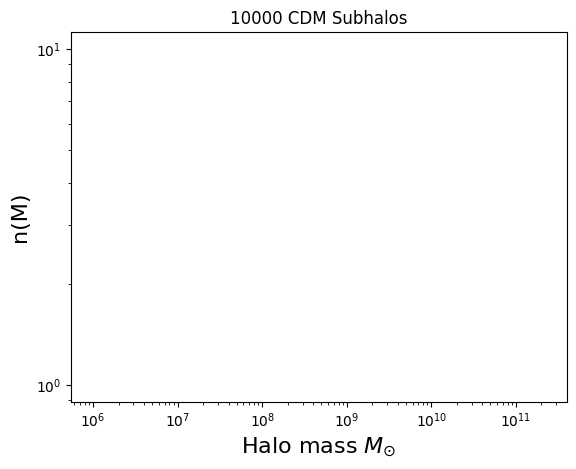

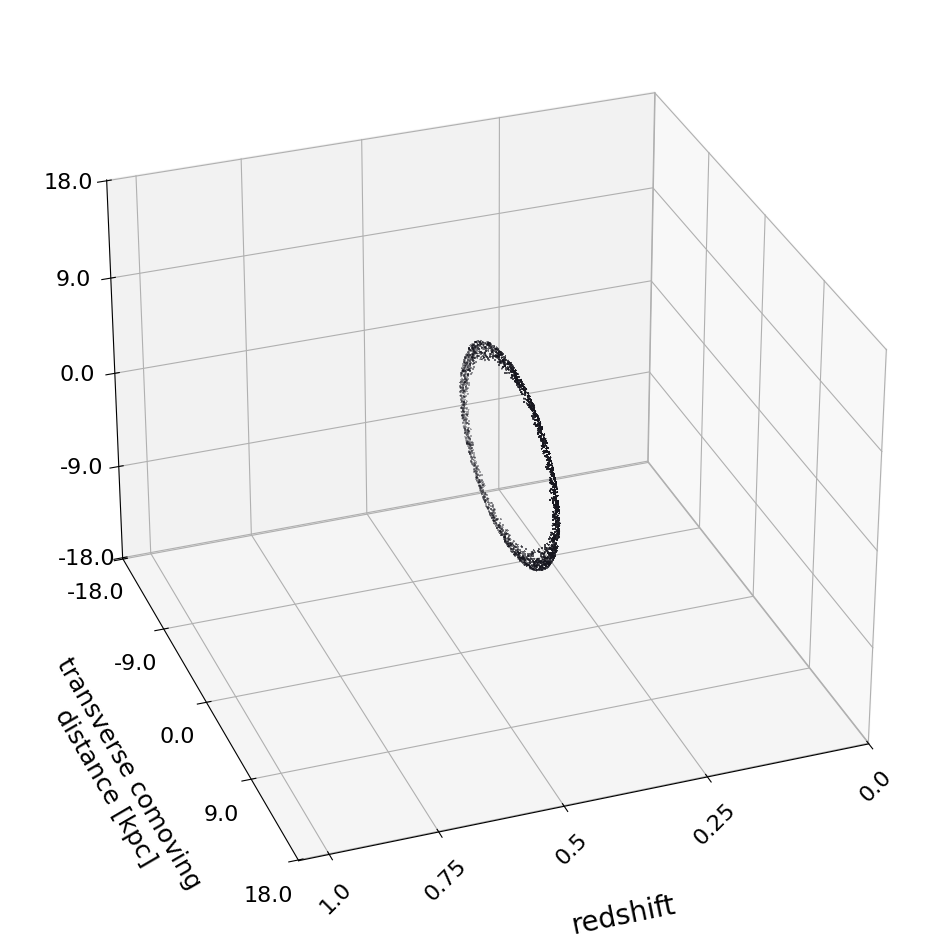

In [7]:
cdm_halo_masses = [halo.mass for halo in realization.halos]
num_subhalos = len(cdm_halo_masses)
N, m = np.histogram(cdm_halo_masses, bins=np.logspace(6, 12, 10))

fig = plt.figure(1)
ax = plt.subplot(111)
ax.loglog(m[0:-1], N)
ax.set_xlabel('Halo mass ' + r'$M_{\odot}$', fontsize=16)
ax.set_ylabel('n(M)', fontsize=16)
ax.set_title(f'{num_subhalos} CDM Subhalos')

fig = plt.figure(figsize=(14, 12))
ax = plt.subplot(111, projection='3d')
realization.plot(ax)

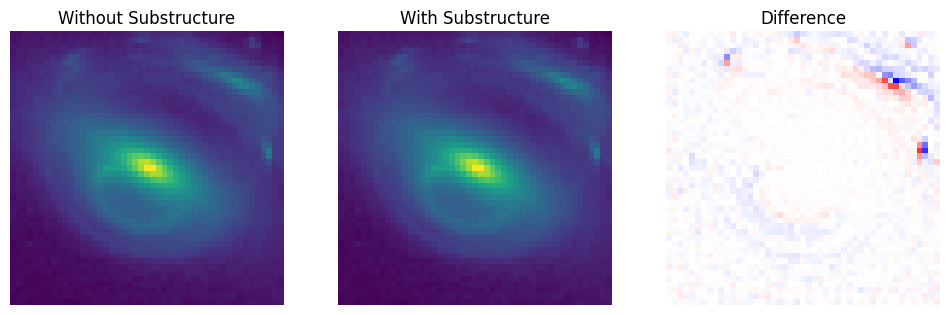

In [8]:
_, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].imshow(exposure.data, norm=LogNorm())
ax[0].set_title('Without Substructure')
ax[0].axis('off')

ax[1].imshow(exposure_with_substructure.data, norm=LogNorm())
ax[1].set_title('With Substructure')
ax[1].axis('off')

ax[2].imshow(exposure_with_substructure.data - exposure.data, norm=CenteredNorm(), cmap='bwr')
ax[2].set_title('Difference')
ax[2].axis('off')

plt.show()